In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd 

In [30]:
df = pd.read_csv("../data/processed/churn_cleaning.csv")

In [31]:
df = df.drop('Churn', axis=1)
X = df.drop('Churn_binary', axis=1)
y = df["Churn_binary"]

In [32]:
X.columns
y

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn_binary, Length: 7032, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [34]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

0.8374756045162058


In [35]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=55)
rf.fit(X_train, y_train)

xgb = XGBClassifier(scale_pos_weight=3, use_label_encoder=False, eval_metrics="logloss", random_state=55)
xgb.fit(X_train, y_train)

c:\Users\aruzh\Projects\churn-prediction-final\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:38:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [36]:
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.87      0.77      0.81      1033
           1       0.51      0.68      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407

0.38235682374683577


c:\Users\aruzh\Projects\churn-prediction-final\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [37]:
models = {"Logistic Regression": lr,
        "Random Forest": rf,
        "XGBoost": xgb}
for name, model in models.items():
    if name=="Logistic Regression":
        preds = model.predict_proba(X_test_sc)[:,1]
    else:
        preds = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, preds)
    print(f"{name}: AUC = {auc:.4f}")


Logistic Regression: AUC = 0.8375
Random Forest: AUC = 0.8202
XGBoost: AUC = 0.8095


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(XGBClassifier(eval_metric="logloss"), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_model = grid.best_estimator_

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


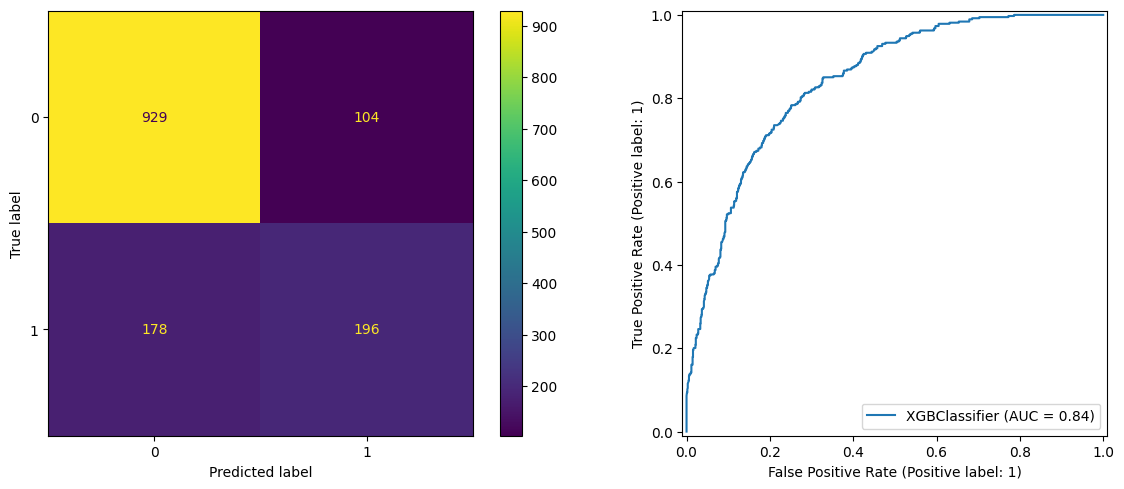

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax1)
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax2)
plt.tight_layout()

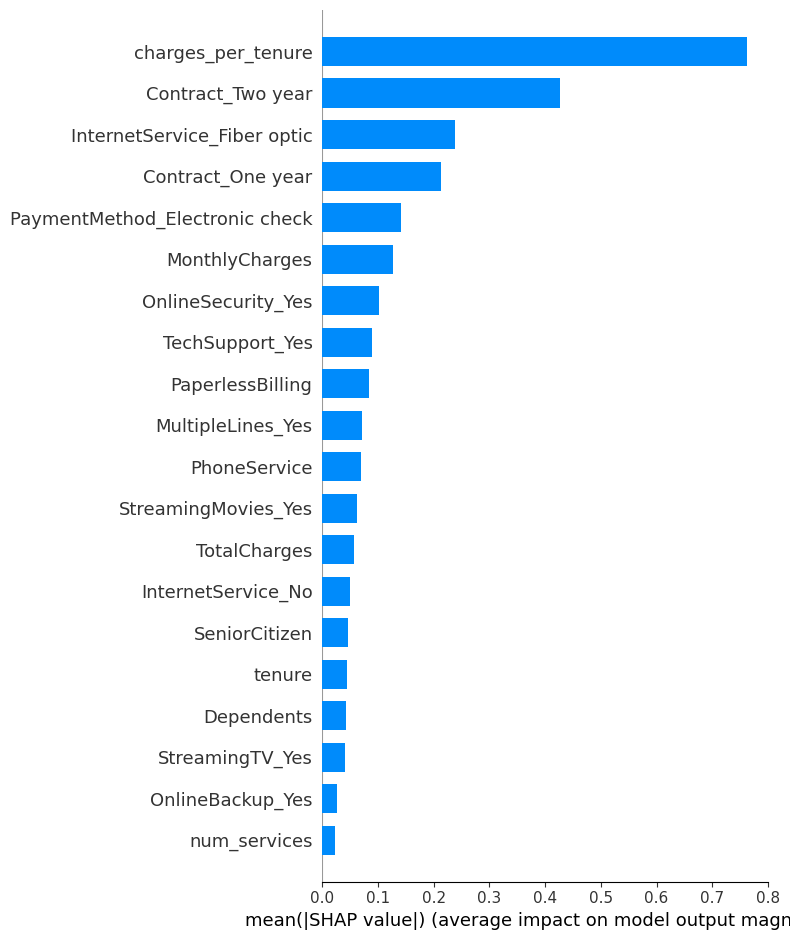

In [41]:
import shap 
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [44]:
import joblib 
import os 

if not os.path.exists("../data/models"):
    os.makedirs("../data/models")

joblib.dump(best_model, '../data/models/churn_model.pkl')
joblib.dump(scaler, '../data/models/scaler.pkl')

['../data/models/scaler.pkl']